# Design Summary
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

The final rollup of the design pipeline. Everything printed here is
**read from the `out/` handoffs the preceding fourteen notebooks wrote**
(plus one sizing-loop re-run to echo the closure, same pattern as every
notebook since NB2) — this notebook adds no new physics and writes no
handoff. It exists so a reader (or a release snapshot) has one place with:

1. the converged design point and the as-selected reality next to it,
2. the flown **mission profile** (range, climb, endurance) with the pack
   state-of-charge tracked leg-by-leg,
3. the control / vibration / thermal / drag margins in one table,
4. the frozen COTS hardware list, and
5. **every standing finding** the pipeline carries, collected
   programmatically from the handoffs — nothing here is hand-maintained.

The mission profile is a *presentation* of the sized design point: its leg
powers and energies are exactly what the mass closure billed, re-summed and
decomposed into flown legs (`mission_profile.py`) — it never re-sizes anything.

## Inputs

Everything in `out/` (NB1–NB14). No outputs.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # bare-checkout fallback

from conceptual_design.notebook import nb_setup
from conceptual_design.design_point import load_handoff, solve_design_point
from conceptual_design.mission_profile import build_mission_profile
from conceptual_design import design_summary as ds
from conceptual_design.plots import plot_budget_margins, plot_mission_profile

nb = nb_setup()
REPO_ROOT, CONFIG_PATH, OUT_PATH, FIG_DIR = (
    nb.repo_root, nb.config, nb.out, nb.fig_dir)

# Section 1 — Design Point at a Glance

Re-run the sizing loop from `config/` and cross-check it against the
frozen-hardware echo (`out/components.yaml`) — a mismatch means stale
handoffs, not new physics.

---

In [2]:
# -- Re-run the design point; collect every handoff (this NB writes nothing) ---
inp, result = solve_design_point(CONFIG_PATH)

af       = load_handoff(OUT_PATH, "airfoil")
vanes    = load_handoff(OUT_PATH, "control_vanes")
ail      = load_handoff(OUT_PATH, "aileron")
ail_cots = load_handoff(OUT_PATH, "aileron_cots")
vib      = load_handoff(OUT_PATH, "vibration")
vib_cots = load_handoff(OUT_PATH, "vibration_cots")
fus      = load_handoff(OUT_PATH, "fuselage")
fus_cots = load_handoff(OUT_PATH, "fuselage_cots")
thermal  = load_handoff(OUT_PATH, "thermal")
elec     = load_handoff(OUT_PATH, "electrical")
massprop = load_handoff(OUT_PATH, "mass_properties")
comp     = load_handoff(OUT_PATH, "components")

# handoff freshness: the COTS freeze must echo this run's closure
assert abs(comp["design_point"]["MTOW_kg"] - result.m_total_kg) < 5e-3, (
    "out/components.yaml design-point echo != sizing re-run -- stale handoffs")

ds.print_glance(result, inp.mission, inp.rotor, inp.wf, af, elec, fus,
                fus_cots, massprop, comp)

VEHICLE AT A GLANCE
--------------------------------------------------------------
MTOW (mass closure)               : 2.518 kg
All-up, as-selected hardware      : 2.336 kg (-182 g standing findings)
Hover / design power              : 743 / 743 W
Pack                              : 6S 22.2 V, 4.12 Ah sized (hover 33.5 A)
Mission                           : 120 s hover + 40 s transition + 900 s cruise = 17.7 min
Wing                              : b 1063 mm, S 0.1883 m^2, MAC 177.1 mm, NACA 4412
Rotor                             : 203 mm, Master Airscrew 3-blade 8x6 prop (in airframe duct, EST)
Fuselage (conceptual / as-sel.)   : 98 x 491 mm  /  107 x 533 mm
CG / static margin                : 242.3 mm from nose, 5% MAC
Inertia (body FRD, about CG)      : Ixx 0.0229, Iyy 0.0453, Izz 0.0579 kg m^2
Construction                      : segmented_fdm (ADR-0008/0010), structure 330 g (as-sel. hull 377 g)


# Section 2 — Mission Profile

The flown timeline built from the converged design point (`mission_profile.py`):
vertical takeoff/climb to the cruise altitude, out-transition, cruise, back-
transition, and vertical descent. This adds **no new physics** — the leg powers
are the same `P_vtol` / `P_cruise` the mass closure sized against, so the leg
energies re-sum to the loop's `E_hover + E_transition + E_cruise` (checked in
the builder). Only the kinematics are new: the vertical legs climb/descend
`h_cruise` at `rate_of_climb`, and range is `V_cruise · t_cruise`.

Battery **state-of-charge is referenced to the sized pack** (which already
carries the reserve factor), so the mission starts at 100% and lands at the
reserve floor `1 − 1/reserve` — the flat cruise burns the bulk of the range but
the short hover/transition legs dominate the *rate* of discharge.

---

MISSION PROFILE
--------------------------------------------------------------
Endurance (hover+transition+cruise)   : 17.7 min
Cruise range (ground track)           : 18.0 km
Cruise altitude AGL                   : 120 m
Vertical climb                        : 120 m at 2.5 m/s (48 s)
Pack energy (sized, incl. reserve)    : 71.2 Wh
Mission energy (nominal, no reserve)  : 59.3 Wh
Pack SoC at landing                   : 17% (17% reserve held)



,phase,dt_s,power_W,alt_m,range_km,E_Wh,SoC_%
leg,,,,,,,
takeoff climb + hover,vtol,60.0,743.0,0->120,0.0,12.4,100->83
transition to cruise,transition,20.0,743.0,120->120,0.0,4.1,83->77
cruise,cruise,900.0,105.0,120->120,18.0,26.3,77->40
transition to hover,transition,20.0,743.0,120->120,18.0,4.1,40->34
descent + landing,vtol,60.0,743.0,120->0,18.0,12.4,34->17


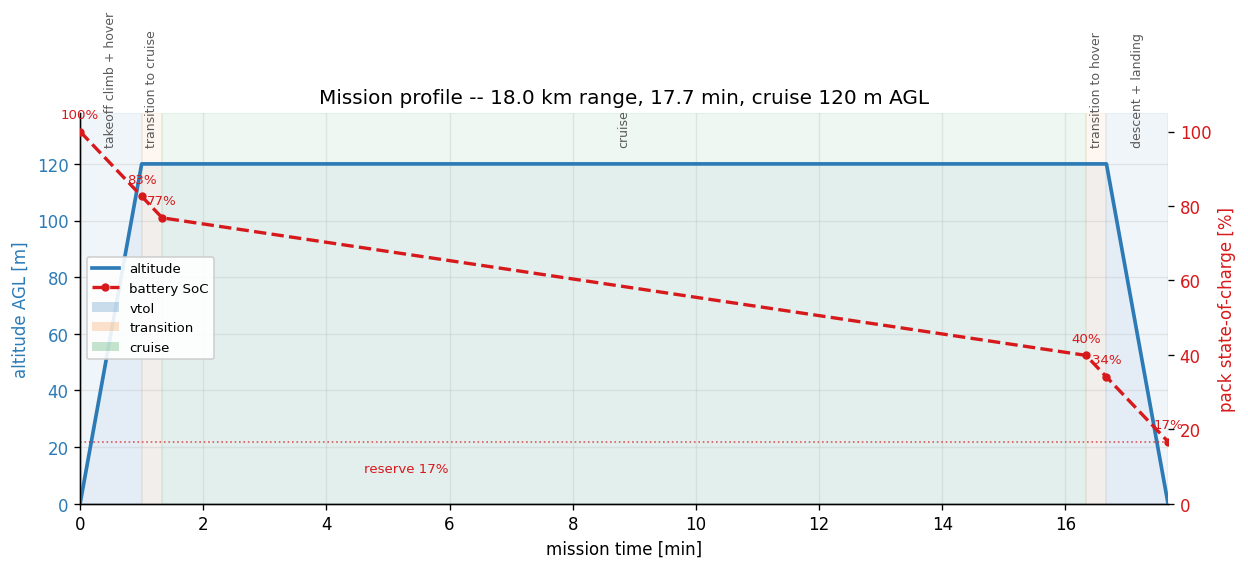

In [3]:
# -- Build the flown timeline + battery track from the converged design point --
profile = build_mission_profile(result, inp.mission)

ds.print_mission_profile(profile)
print()
plot_mission_profile(profile, FIG_DIR / "design_summary_mission.png")
display(ds.mission_profile_table(profile))

# Section 3 — Mass: Closure Allocations vs. As-Selected Hardware

Same idiom as the NB11 budget chart (bar = actual hardware, tick =
allocation, red = over), for the five COTS groups of the freeze. The +/-
labels carry the numbers so the verdict never rides on color alone; the
all-up rollup (which would dwarf the group bars) is reported as text.

---

FINDING avionics_bay  :   138.6 g vs   113.4 g (  -25.2 g)
ok      esc           :    30.0 g vs    94.4 g (  +64.4 g)
FINDING motor_fan     :   306.0 g vs   226.6 g (  -79.4 g)
ok      servo_each    :     8.9 g vs    12.0 g (   +3.1 g)
ok      battery       :   450.0 g vs   653.3 g ( +203.3 g)

All-up rollup (NB14): 2336 g as-selected vs 2518 g closure MTOW (-182 g)


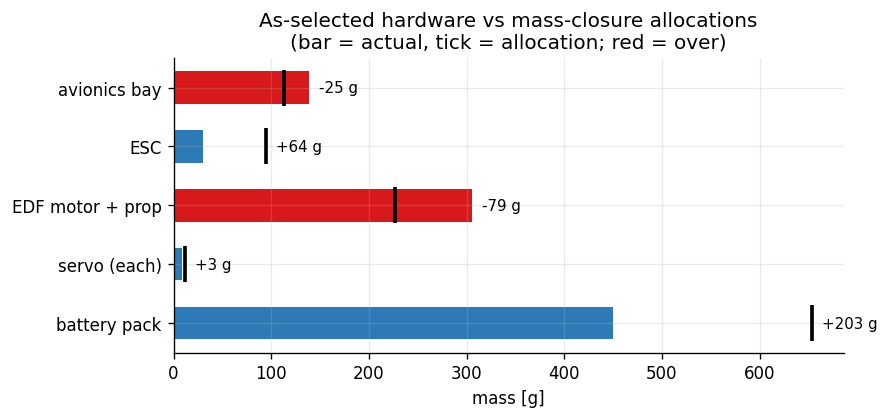

In [4]:
labels = {
    "avionics_bay": "avionics bay",
    "esc":          "ESC",
    "motor_fan":    "EDF motor + prop",
    "servo_each":   "servo (each)",
    "battery":      "battery pack",
}
plot_budget_margins(
    comp["budgets"], ds.BUDGET_GROUPS, labels,
    "As-selected hardware vs mass-closure allocations\n"
    "(bar = actual, tick = allocation; red = over)",
    FIG_DIR / "design_summary_mass.png")

ds.print_budget_lines(comp["budgets"], fus_cots)

# Section 4 — Margins in One Table

Control authority (hover and cruise), servo torque, vibration isolation,
thermal paths, and the cruise drag budget — each against the requirement
its own notebook checked, with the notebook that owns it.

---

In [5]:
rows = ds.margins_table(vanes, ail, ail_cots, vib_cots, thermal, fus_cots,
                        af, inp.aero)
ds.print_margins_table(rows)

check                       owner  value                 requirement     verdict
----------------------------------------------------------------------------------
hover roll authority        NB3    868 deg/s^2           >= 30           ok
hover pitch authority       NB3    614 deg/s^2           >= 30           ok
cruise roll (ail + vane)    NB12   535 deg/s^2           >= 30           ok
servo stall vs vane req     NB12   x2.9                  >= x1.0         ok
1/rev isolation (FC/IMU)    NB13   90% att.              >= 90%          ok
battery bay venting         NB7    17.9 C margin         > 0 C           ok
ESC cold-plate              NB7    12.2 C margin         mass in alloc   FINDING
pack transient (nominal R)  NB7    65 C end-of-mission   <= 60 C         FINDING
cruise drag budget          NB14   CD0 0.0225            <= 0.0250       ok
frozen parts fit the hull   NB14   4/4 fit               all fit         ok
structure vs budget (as-sel.)NB14   377 g                 <= 386 g

# Section 5 — Frozen COTS Hardware

The procurement list as frozen by NB11 (`out/components.yaml`); `frozen`
means pinned via `selection.frozen` rather than auto-selected. After
procurement: weigh the parts, fix the `EST` entries, pin the remaining
ids, update the regression pins — the diff is the procurement record.

---

In [6]:
display(ds.selected_hardware_table(comp))

,part,id,mass_g,pinned,alternatives
category,,,,,
flight_controller,Holybro Pixhawk 6C (plastic case),pixhawk_6c,34.6,False,4
esc,APD 80F3[X] (KISS/serial telemetry),apd_80f3x,30.0,False,1
edf_motor,SunnySky X4120 KV465 (EST),sunnysky_x4120_465,283.0,False,3
propeller,Master Airscrew 3-blade 8x6 prop (in airframe ...,ma_3blade_8x6,23.0,True,1
servo,"KST X08 V6 (metal gear, digital)",kst_x08_v6,8.9,False,3
battery,Molicel P50B 6S1P 5000 mAh Li-ion (21700),molicel_p50b_6s1p_5000,450.0,False,3
supporting avionics,GPS/telemetry/RX/airspeed/PM/looms,-,104.0,False,0


# Section 6 — Standing Findings

Collected **programmatically** from the handoffs — this list cannot go
stale. Each finding indicts an *assumption* (a weight fraction, a
packaging density, an allocation), not a part: the selections were
already the lightest physics allows.

---

In [7]:
findings = ds.collect_findings(comp, thermal, fus, fus_cots)
ds.print_findings(findings)

5 standing finding(s):

 1. avionics_bay: 139 g vs 113 g allocation (-25 g) -- FC + supporting avionics vs the net avionics-bay budget
 2. motor_fan: 306 g vs 227 g allocation (-79 g) -- EDF motor + fan/prop unit vs the motor_fan layout allocation
 3. ESC cold-plate (ADR-0009): needs 246 cm^2 / 133 g plate vs the ESC allocation; temp margin only 12.2 C
 4. battery pack transient (ADR-0014): nominal 90 mOhm pack ends the mission at 65 C average vs the 60 C limit at hot-day ambient (-5 C) -- measure pack DCIR at procurement; the optimistic 60 mOhm build passes
 5. as-selected hull grows to 107 x 533 mm (+8.4 / +42.0 mm vs conceptual) -- rigid COTS envelopes drive the bay stack; CAD/CFD stay on the conceptual geometry until a config revision adopts this (ADR-0012)


# Section 7 — Closing Summary

---

In [8]:
ds.print_final_card(result, inp.rotor, elec, fus, fus_cots, comp, findings)

      V-BAT-LIKE TAIL-SITTER -- FROZEN CONCEPTUAL DESIGN POINT    
  MTOW (closure) / as-selected        : 2.518 / 2.336 kg
  Hover power / pack                  : 743 W / 6S 4.12 Ah
  Wing / rotor                        : b 1063 mm / D 203 mm (ma_3blade_8x6)
  Fuselage (conceptual/as-sel.)       : 98x491 / 107x533 mm
  Standing findings                   : 5
  Next iteration: procure & weigh the frozen parts, fix the EST
  entries, then fold the as-selected deltas (battery envelope,
  motor mass, avionics stack) into config/ as a reviewed change --
  the pipeline re-converges from there (ADR-0012).
